# CNN Multiclass Classification Tutorial (4 sınıf)
Bu notebook 4 sınıflı bir multiclass problemine çözüm aramaktadır.

In [1]:
# 1) Gerekli Kütüphaneleri İçe Aktarma
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import logging
from sklearn.metrics import classification_report, confusion_matrix
import itertools

# GPU/CPU kontrolü
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        for d in physical_devices:
            tf.config.experimental.set_memory_growth(d, True)
    except Exception as e:
        print('GPU memory growth setup failed:', e)

In [2]:
# 2) Sabitler ve Konfigürasyon
BASE_DIR = Path('dataset_split') / 'multiclass'
RESULTS_DIR = Path('results') / 'multiclass'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
IMG_SIZE = (128, 128)
AUTOTUNE = tf.data.AUTOTUNE
EPOCHS = 20
SEED = 42

# 1) Veri Hazırlama ve Augmentasyon
Normalize ve augmentasyon katmanları tanımlanır.

In [3]:
normalization_layer = layers.Rescaling(1./255)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


# 2) Veri Yükleyicileri: train / val / test
`tf.keras.utils.image_dataset_from_directory` ile veri yüklenir.

In [4]:
train_dir = BASE_DIR / 'train'
val_dir = BASE_DIR / 'val'
test_dir = BASE_DIR / 'test'

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=True,
    seed=SEED,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
print('Classes:', class_names)

Found 320 files belonging to 4 classes.
Found 40 files belonging to 4 classes.
Found 40 files belonging to 4 classes.
Classes: ['CL', 'ML', 'PT', 'UZ']


In [5]:
def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (normalization_layer(x), y), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds = prepare(val_ds, training=False)
test_ds = prepare(test_ds, training=False)

# 2.5) Veri örneklerini göster
Eğitim setinden örnek görüntüler gösterilir.

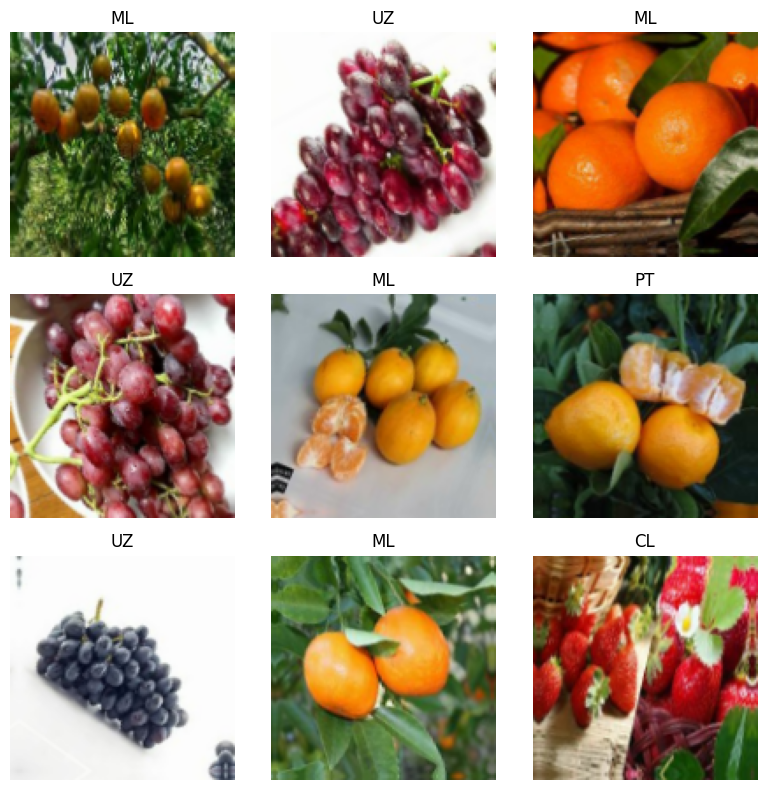

In [9]:
def show_examples(dataset, class_names, num=9):
    plt.figure(figsize=(8,8))
    for images, labels in dataset.take(1):
        images = images.numpy()
        labels = labels.numpy()
        n = min(num, images.shape[0])
        for i in range(n):
            ax = plt.subplot(3,3,i+1)
            img = images[i]
            if np.issubdtype(img.dtype, np.floating):
                maxval = img.max()
                if maxval <= 1.5:
                    img_show = np.clip(img * 255.0, 0, 255).astype('uint8')
                else:
                    img_show = np.clip(img, 0, 255).astype('uint8')
            else:
                img_show = img.astype('uint8')

            if img_show.ndim == 3 and img_show.shape[-1] == 1:
                plt.imshow(img_show.squeeze(-1), cmap='gray')
            else:
                plt.imshow(img_show)
            plt.title(class_names[labels[i]])
            plt.axis('off')
    plt.tight_layout()
    plt.show()

show_examples(train_ds, class_names, num=9)

# 3) CNN Modeli Tanımı (4 sınıf çıkışı, softmax)

In [10]:
def make_model(input_shape=(*IMG_SIZE, 3), num_classes=None):
    if num_classes is None:
        num_classes = len(class_names)
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPool2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model

model = make_model()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 activation (Activation)     (None, 128, 128, 32)      0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496 

# 4) Modeli Derleme

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5) Eğitim (fit)

In [ ]:
checkpoint_path = RESULTS_DIR / 'best_multiclass_model.h5'
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS)

Epoch 1/20
10/10 [==============================] - 1s 48ms/step - loss: 0.6783 - accuracy: 0.7281 - val_loss: 1.1711 - val_accuracy: 0.5250
Epoch 2/20
10/10 [==============================] - 1s 45ms/step - loss: 0.7069 - accuracy: 0.6906 - val_loss: 1.1422 - val_accuracy: 0.5250
Epoch 3/20
10/10 [==============================] - 1s 44ms/step - loss: 0.6909 - accuracy: 0.6875 - val_loss: 1.1120 - val_accuracy: 0.5250
Epoch 4/20
10/10 [==============================] - 1s 46ms/step - loss: 0.6656 - accuracy: 0.7031 - val_loss: 1.0769 - val_accuracy: 0.5500
Epoch 5/20
10/10 [==============================] - 1s 44ms/step - loss: 0.6619 - accuracy: 0.6844 - val_loss: 1.0501 - val_accuracy: 0.5750
Epoch 6/20
10/10 [==============================] - 1s 44ms/step - loss: 0.6121 - accuracy: 0.7531 - val_loss: 1.0274 - val_accuracy: 0.5500
Epoch 7/20
10/10 [==============================] - 1s 43ms/step - loss: 0.5922 - accuracy: 0.7656 - val_loss: 1.0001 - val_accuracy: 0.5750
Epoch 8/20
10

# 6) Eğitim Sonrası: Kayıtlı Grafikler ve Değerlendirme

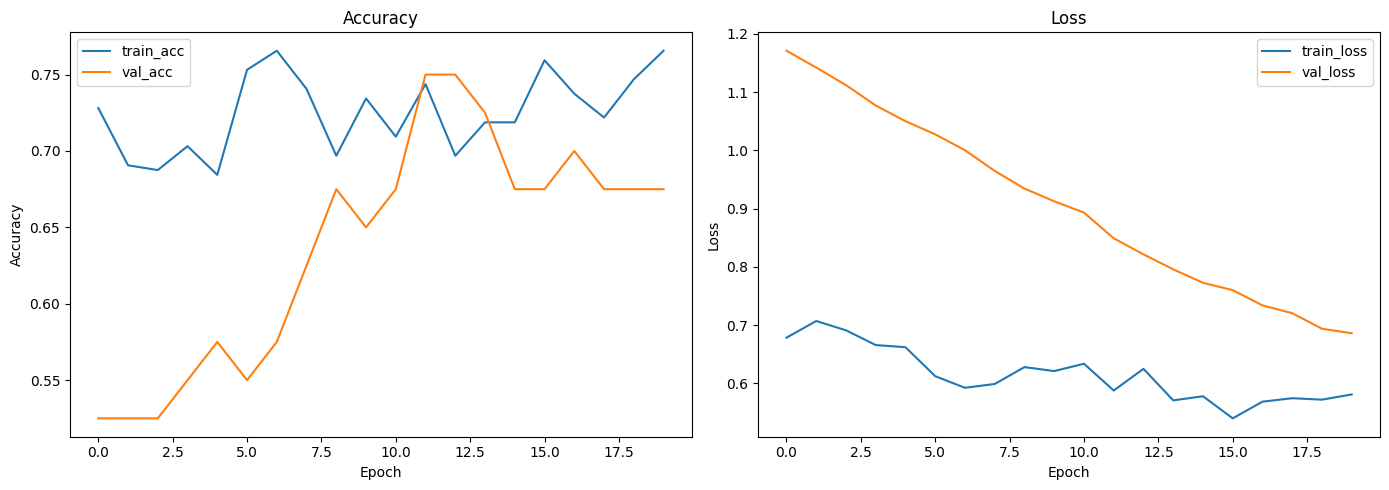

In [15]:
import matplotlib.pyplot as plt

if 'history' in globals() and hasattr(history, 'history'):
    h = history.history
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(h.get('accuracy', []), label='train_acc')
    axes[0].plot(h.get('val_accuracy', []), label='val_acc')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(h.get('loss', []), label='train_loss')
    axes[1].plot(h.get('val_loss', []), label='val_loss')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plots_path = RESULTS_DIR / 'training_plots.png'
    plt.savefig(str(plots_path))
    plt.show()
else:
    print('No `history` object found in the notebook namespace.')

In [17]:
loss, acc = model.evaluate(test_ds)

# Predictions on test set
y_true = []
y_pred = []
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch)
    preds_idx = np.argmax(preds, axis=1)
    y_true.extend(y_batch.numpy().tolist())
    y_pred.extend(preds_idx.tolist())

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)
print('Confusion matrix:\n', cm)

1/1 [==============================] - 0s 66ms/step
              precision    recall  f1-score   support

          CL       0.83      1.00      0.91        10
          ML       0.75      0.30      0.43        10
          PT       0.53      0.80      0.64        10
          UZ       1.00      0.90      0.95        10

    accuracy                           0.75        40
   macro avg       0.78      0.75      0.73        40
weighted avg       0.78      0.75      0.73        40

Confusion matrix:
 [[10  0  0  0]
 [ 0  3  7  0]
 [ 1  1  8  0]
 [ 1  0  0  9]]


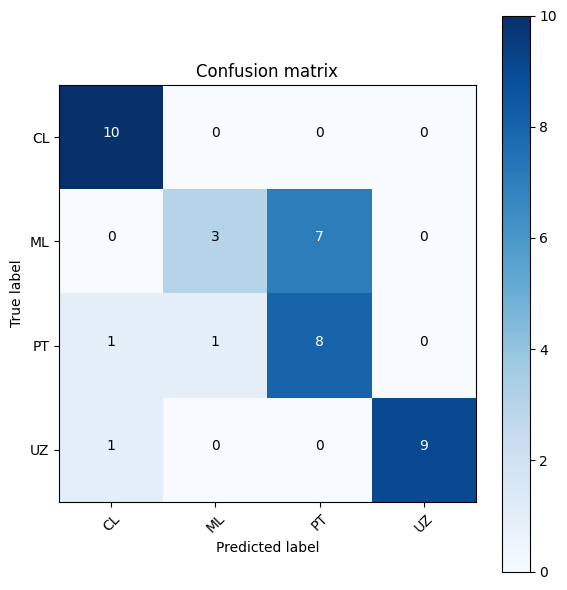

In [18]:
def plot_confusion_matrix(cm, classes):
    plt.figure(figsize=(6,6))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, class_names)

# 7) Modeli Kaydetme ve Yükleme

In [ ]:
model.save(str(RESULTS_DIR / 'final_multiclass_model'))
# loaded = tf.keras.models.load_model(str(RESULTS_DIR / 'final_multiclass_model')) # Örnek yükleme:

INFO:tensorflow:Assets written to: results\multiclass\final_multiclass_model\assets


INFO:tensorflow:Assets written to: results\multiclass\final_multiclass_model\assets


# 8) Tahmin Görselleştirme (örnek görüntüler)

1/1 [==============================] - 0s 19ms/step


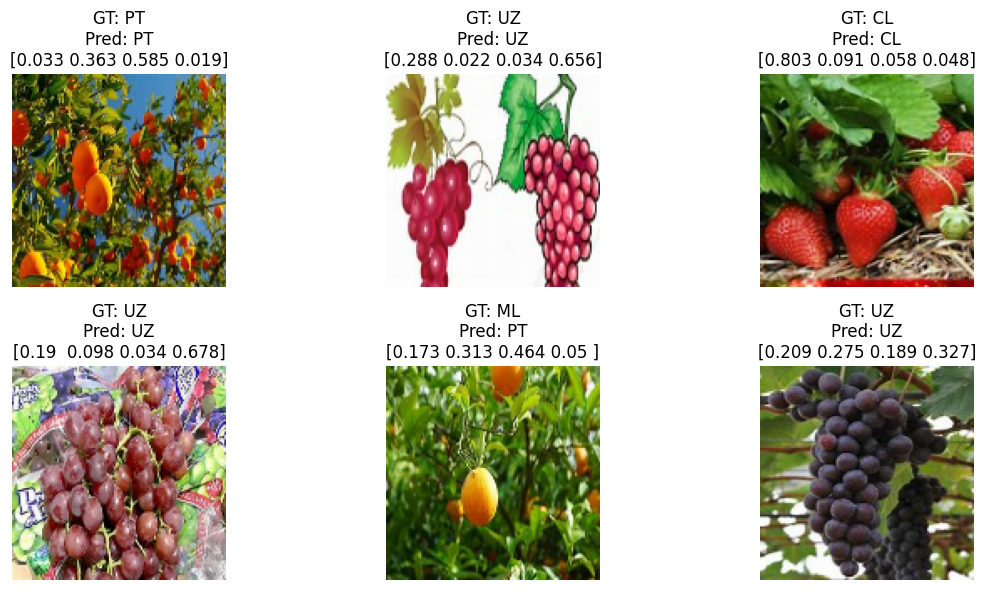

In [24]:
from PIL import Image, ImageOps

def show_predictions(dataset, model, class_names, num=6):
    images_list = []
    labels_list = []
    preds_list = []
    probs_list = []
    for x_batch, y_batch in dataset.unbatch().shuffle(1000, seed=SEED).batch(1).take(num):
        img = x_batch.numpy()[0]
        lbl = int(y_batch.numpy()[0])
        pred_probs = model.predict(x_batch)[0]
        pred_idx = int(np.argmax(pred_probs))
        images_list.append(img)
        labels_list.append(lbl)
        preds_list.append(pred_idx)
        probs_list.append(pred_probs)

    cols = 3
    rows = (len(images_list) + cols - 1) // cols
    plt.figure(figsize=(cols * 4, rows * 3))
    for i, img in enumerate(images_list):
        ax = plt.subplot(rows, cols, i+1)
        img_show = np.clip(img * 255.0, 0, 255).astype('uint8')
        if img_show.ndim == 3 and img_show.shape[-1] == 1:
            plt.imshow(img_show.squeeze(-1), cmap='gray')
        else:
            plt.imshow(img_show)
        plt.title(f"GT: {class_names[labels_list[i]]}\nPred: {class_names[preds_list[i]]}\n{np.round(probs_list[i],3)}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Call the helper to show a few predictions from the test set
show_predictions(test_ds, model, class_names, num=6)